# Acoustic Scan 

In [1]:
# matching pursuit
# depth profiling
# attenuation with high f. reflection ok, transmission no
# look at acoustic resonances, dip in attenuation
# 

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
from matplotlib import pyplot as plt
import sys


sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonicTesting')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/M3Learning-Util/src')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/AutoPhysLearn/src')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonic_ml/src')


from scipy.signal import butter, sosfiltfilt
import copy
import math
import time
from tqdm import tqdm
import pickleJar as pj
import tomography as tm

In [3]:
from viz.visualize_scan_data import *
from IPython.display import display
import plotly.graph_objects as go

## Dataloader with preprocessing

In [4]:
from data import datasets
from data.datasets import morlet_1D_dataset_real

dset = morlet_1D_dataset_real(sq3lite_path='/Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_foil_tape_scan.sqlite3',
                              # dset_name='voltage_transmission_forward',
                              dset_name='voltage_echo_forward',
                              image_shape = (1,1),
                            #   crops = [(0,4000)] #(15000,19000)
                            ) 

# dset.preprocess_data_additional(np.max, 'max')

sqliteToPickle Warning: pickle file /Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_foil_tape_scan.pickle already exists. Conversion aborted.
preprocessing data...


  0%|          | 0/1911 [00:00<?, ?it/s]/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonicTesting/pickleJar.py:1185: RuntimeWarning: divide by zero encountered in log10
  logData = np.log10(abs(data))
100%|██████████| 1911/1911 [00:01<00:00, 1648.27it/s]


In [60]:
20e-6/10000

2e-09

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_8485/2656105359.py:34: RuntimeWarning: divide by zero encountered in divide
  axs[3,0].plot(freqs[viz_crop[0]:viz_crop[1]]*dset.dt, phase[viz_crop[0]:viz_crop[1]]/freqs[viz_crop[0]:viz_crop[1]]/2) # /2 bc 2 ns per sample
/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_8485/2656105359.py:50: RuntimeWarning: divide by zero encountered in divide
  axs[3,1].plot(freqs[viz_crop[0]:viz_crop[1]]*dset.dt, phase[viz_crop[0]:viz_crop[1]]/freqs[viz_crop[0]:viz_crop[1]]/2) # /2 bc 2 ns per sample
/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_8485/2656105359.py:65: RuntimeWarning: divide by zero encountered in divide
  axs[3,2].plot(freqs[viz_crop[0]:viz_crop[1]]*dset.dt, phase[viz_crop[0]:viz_crop[1]]/freqs[viz_crop[0]:viz_crop[1]]/2) # /2 bc 2 ns per sample


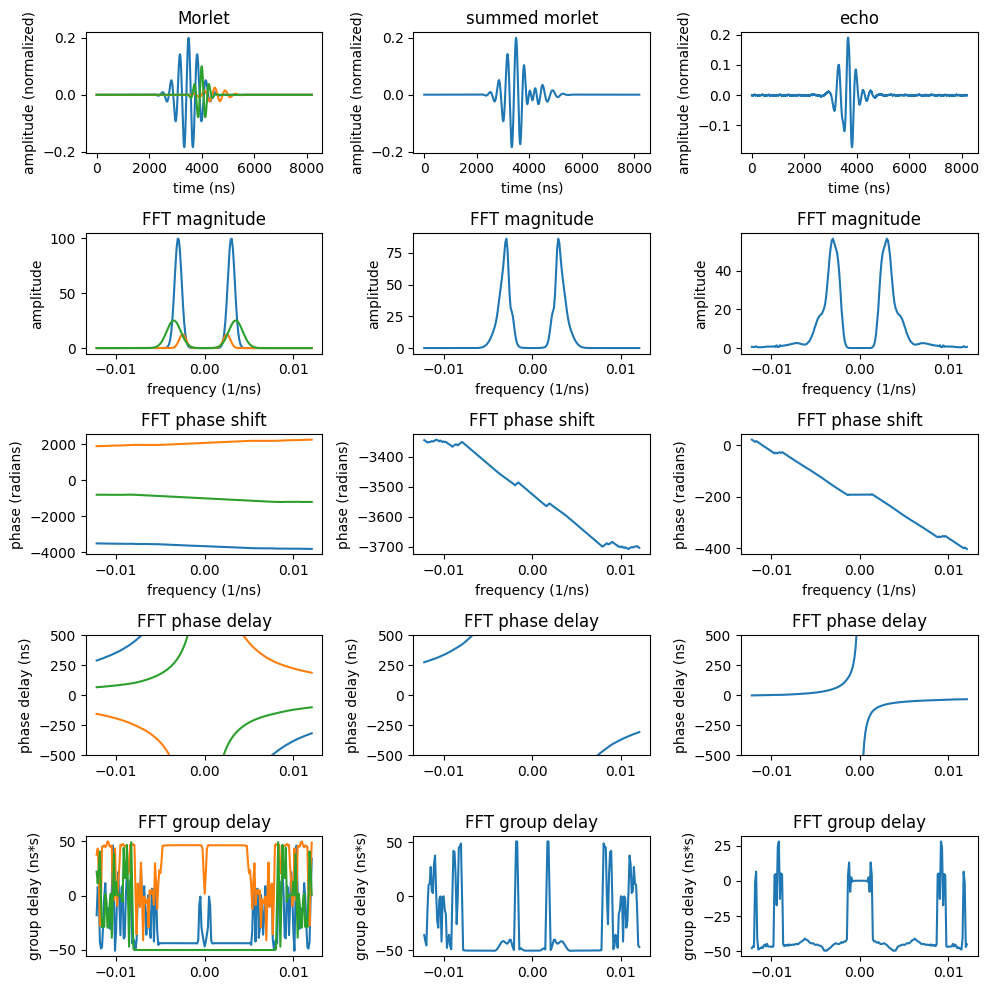

In [62]:
import torchaudio
import matplotlib.pyplot as plt
import torch
import numpy as np
from models.morlet_fitter import morlet_1D_fitters_real

i = 1034
data_crop = 2**13
fig, axs = plt.subplots(5, 2, figsize=(10, 10))

sample_rate = float(1.0 / dset.dt)
# Same window/hop as default torchaudio Spectrogram (n_fft=400, hop=win_length/2=200)
N_FFT, HOP = 400, 200
# Match torchaudio: power=2.0, same STFT; use for log2 mag image like the small torchaudio example
spec_pow = torchaudio.transforms.Spectrogram(
    n_fft=N_FFT, hop_length=HOP, power=2.0, center=True
)
win = torch.hann_window(N_FFT)
freqs = np.fft.rfftfreq(N_FFT, d=1.0 / sample_rate)
omega = 2.0 * np.pi * freqs
omega[0] = omega[1]  # avoid DC divide


def to_torch1d(wave_1d):
    return torch.as_tensor(wave_1d, dtype=torch.float32).reshape(-1)


def stft_complex(wave_1d):
    w = to_torch1d(wave_1d)
    S = torch.stft(
        w,
        n_fft=N_FFT,
        hop_length=HOP,
        win_length=N_FFT,
        window=win.to(w.device),
        center=True,
        return_complex=True,
    )
    return S.cpu().numpy()


def stft_ims(wave_1d):
    S = stft_complex(wave_1d)
    phase = np.unwrap(np.angle(S), axis=0)
    t_delay_ns = -phase / omega[:, None] * 1e9
    dphi_df = np.apply_along_axis(
        lambda p: np.gradient(p, freqs), 0, phase
    )  # slice along rows = phase vs freq; axis 1 would be time, wrong for len(freqs)
    g_delay_ns = -(dphi_df) / (2.0 * np.pi) * 1e9
    return phase, t_delay_ns, g_delay_ns


def imshow2d(X, ax, title, cbar_label=None, cmap="magma", robust=True, vmin=None, vmax=None):
    if vmin is None and vmax is None and robust:
        vmin, vmax = np.nanpercentile(X, 1), np.nanpercentile(X, 99)
    m = ax.imshow(X, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    if cbar_label is not None:
        plt.colorbar(m, ax=ax, label=cbar_label)


def spec_log2(ax, w_1d, title):
    w = to_torch1d(w_1d).unsqueeze(0)
    P = spec_pow(w).squeeze(0).numpy()
    imshow2d(np.log2(P + 1e-20), ax, title, cmap="magma")


def plot_column(wave, col, title_tag):
    y = np.asarray(wave, dtype=np.float32)
    phase, t_delay, g_delay = stft_ims(wave)
    axs[0, col].set_title(f"{title_tag} (time)")
    axs[0, col].plot(y)
    axs[0, col].set_xlabel("sample")
    axs[0, col].set_ylabel("amplitude (normalized)")

    spec_log2(
        axs[1, col], wave, f"{title_tag}: FFT spectrogram (log2 power, torchaudio)"
    )

    imshow2d(phase, axs[2, col], f"{title_tag}: STFT phase (unwrap along freq)", cmap="twilight", cbar_label="rad")
    imshow2d(
        t_delay,
        axs[3, col],
        f"{title_tag}: phase delay (−φ/ω)",
        cbar_label="ns",
        robust=False,
        vmin=-500,
        vmax=500,
    )  # match original 1D phase-delay row (ns)
    imshow2d(
        g_delay, axs[4, col], f"{title_tag}: group delay (−(dφ/df)/2π)", cbar_label="ns"
    )

    for r in (1, 2, 3, 4):
        axs[r, col].set_xlabel("time frame (hop)")
    axs[1, col].set_ylabel("freq bin")
    for r in (2, 3, 4):
        axs[r, col].set_ylabel("freq bin")


morlet_class = morlet_1D_fitters_real(
    limits=[1, dset.spec_len, dset.spec_len / 5, 0.05]
)
pars = torch.tensor(
    [
        [
            [0.2, 3500, 400, 3.0e-03],
            [0.025, 4500, 400, 2.5e-03],
            [0.1, 4000, 200, 3.5e-03],
        ],
    ]
)

test_ = morlet_class.generate_fit(pars, data_crop)
test_morlet_sum = test_.sum(axis=1)[0].numpy()
test_echo = dset.data["processed_voltage_echo_forward"][i][:data_crop]

plot_column(test_morlet_sum, 0, "summed morlet")
plot_column(test_echo, 1, "echo")
fig.tight_layout()


In [5]:
# ## SAVE CELL
# dat = pj.loadPickle('/Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_foil_tape_scan.pickle')
# # dat['parameters']
# # omega_ = dat['parameters']['measureTime']*1e-6/dat['parameters']['samples']*2.25e6
# # omega_

# # for i in range(len(dat)-2):
# dat['parameters']


In [6]:
# dset.display_dict_tree()

## Interactive Viewer with Slider

Use the slider below to browse through all scans interactively.

In [7]:
# vals = abs(dset[:][1]).max(axis=1)
# plt.imshow(vals.reshape(dset.image_shape))
# plt.colorbar()

In [8]:
# Create interactive viewer with slider
from viz.visualize_scan_data import plotly_viewer
    
plotly_viewer(dset)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

...

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## try training model with morlet packet

goals:
- figure out mean position and f of morlet packet
- using this, calculate speed of sound in this water

In [20]:
from models.morlet_fitter import Fitter_AE, morlet_1D_fitters_real
from autophyslearn.spectroscopic.nn import block_factory, Conv_Block, FC_Block  # pyright: ignore[reportMissingImports]
from autophyslearn.spectroscopic.nn import Multiscale1DFitter
# from data.custom_sampler import Gaussian_Sampler
import torch

num_fits = 4 # number of curves to sum up
num_params = 4 # number of parameters to fit
# todo: change wandb naming to include noise level, group and regularization technique
# todo: test more num fits
model = Fitter_AE(function=morlet_1D_fitters_real,
                dset=dset,
                num_params=num_params,
                num_fits=num_fits,
                checkpoints_label='ultrasound_water',
                input_channels = 1,
                learning_rate=1e-4,
                device='cpu',
                encoder = Multiscale1DFitter,
                encoder_params = {
                    "model_block_dict": { # factory wrapper for blocks
                            "hidden_x1": block_factory(Conv_Block)(output_channels_list=[128,128], 
                                                                    kernel_size_list=[111,11], 
                                                                    pool_list=[1000,100], 
                                                                    max_pool=False),
                            "hidden_xfc": block_factory(FC_Block)(output_size_list=[128,64]), # remove 2nd block and skip connections
                            "hidden_x2": block_factory(Conv_Block)(output_channels_list=[32,16], 
                                                                    kernel_size_list=[5,3], 
                                                                    pool_list=[64,32], 
                                                                    max_pool=True),
                            "hidden_embedding": block_factory(FC_Block)(output_size_list=[8*num_fits,num_params*num_fits], last=True),
                        },
                        # TEST: LIMITS,
                        "skip_connections": {'hidden_xfc': 'hidden_embedding'},
                        # "skip_connections": {},
                        "function_kwargs": {'limits': [1, # amplitude
                                                       dset.spec_len, # mean
                                                       dset.spec_len/5, # stdev
                                                       0.05 # +-1% of the angular frequency scaled for step size
                                                        ]
                                                       
                                                    #    1e-2] # freq max (100 MHz)
                                            } 
                    },
                )


### Train model for several epochs


In [21]:
# import wandb
# wandb.init(group='sub_sampler_type', name='sub_noise_level') # later change config for regularization

model.train(epochs=5,save_every=10, batch_size=10, log_wandb=False, 
            # lr_scheduling=True,
            # coef1=1e-3
            )

/Users/xz498/Desktop/ultrasound project/data analysis/example data/ultrasound_water/checkpoints/voltage_echo_forward


100%|██████████| 192/192 [00:22<00:00,  8.72it/s]


Epoch: 000/005 | Train Loss: 0.0346
.............................


100%|██████████| 192/192 [00:25<00:00,  7.55it/s]


Epoch: 001/005 | Train Loss: 0.0047
.............................


...

Epoch: 002/005 | Train Loss: 0.0025
.............................


100%|██████████| 192/192 [00:22<00:00,  8.36it/s]


Epoch: 003/005 | Train Loss: 0.0021
.............................


100%|██████████| 192/192 [00:23<00:00,  8.31it/s]

Epoch: 004/005 | Train Loss: 0.0020
.............................


### Embeddings

In [22]:
def write_scaled_embedding(batch_size=1):
    model.dataloader.batch_size
    fits = np.zeros((dset.shape[0],model.num_fits,dset.shape[-1]))
    params = np.zeros((dset.shape[0],model.num_fits,4))
    for i, (idx, x) in enumerate(tqdm(model.dataloader, leave=True, total=len(model.dataloader))):
        with torch.no_grad():
            f, p = model.encoder(x.float().to(model.device))
            fits[idx] = f.cpu().numpy()
            params[idx] = p.cpu().numpy()
            # params[idx] = np.append(p.cpu().numpy(), np.full((len(idx),num_fits,1), 4500.0), axis=-1,)
    return fits, params


fits, params = write_scaled_embedding(batch_size=1)

# sweep frequencies and search for resonances 
# attenuation in each layer accounts for spherical nature of wave
# data for one to 20 layers
# measure waveform from 30-50, measuring thermal gradient. shoul dbe the same as 40 (mean), so why isnt it?
# goal: use ultrasound to monitor the thermal expansion so we can decreasing charging rate. this way the battery is less likely to experience stress and can cycle more

100%|██████████| 192/192 [00:09<00:00, 20.26it/s]


In [23]:
from viz.visualize_scan_data import training_viewer
x,z = 6,25
training_viewer(dset, fits, params, idx=x*dset.image_shape[1]+z)
    